# Интеллектуальный анализ данных – весна 2025
# Домашнее задание 6: классификация текстов

Правила:



*   Домашнее задание оценивается в 10 баллов.
*   Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.
*  Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.
*  Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.
*  Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.
* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

В этом домашнем задании вам предстоит построить классификатор текстов.

Будем предсказывать эмоциональную окраску твиттов о коронавирусе.



In [ ]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [ ]:
df = pd.read_csv('/content/tweets_coronavirus.csv', encoding='latin-1')
df.sample(4)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
20209,28441,73393,NaN,27-03-2020,@piersmorgan #coronavirus means nothing to the...,Negative
2601,6945,51897,Citizen of Nowhere,18-03-2020,Number of my clients are struggling to know wh...,Positive
8724,14394,59346,northampton,20-03-2020,@hughlaurie Why not pitch in and help pay towa...,Negative
5536,10523,55475,Cheshire.,19-03-2020,"Its not great, not where you thought youÃÂd ...",Negative


Для каждого твитта указано:


*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твитта
*   OriginalTweet - текст твитта
*   Sentiment - эмоциональная окраска твитта (целевая переменная)



## Задание 1 Подготовка (0.5 балла)

Целевая переменная находится в колонке `Sentiment`.  Преобразуйте ее таким образом, чтобы она стала бинарной: 1 - если у твитта положительная или очень положительная эмоциональная окраска и 0 - если отрицательная или очень отрицательная.

In [ ]:
df['Sentiment_Coded'] = df['Sentiment'].apply(lambda x: 1 if x == 'Positive' or x == 'Extremely Positive' else 0)

Сбалансированы ли классы?

In [ ]:
df[df['Sentiment_Coded'] == 0].shape

(15398, 7)

In [ ]:
df[df['Sentiment_Coded'] == 1].shape

(18046, 7)

**Ответ:** Классы сбалансированы

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их строкой 'Unknown'.

In [ ]:
df.isna().sum()

,0
UserName,0
ScreenName,0
Location,7049
TweetAt,0
OriginalTweet,0
Sentiment,0
Sentiment_Coded,0


In [ ]:
df = df.fillna('Unknown')

In [ ]:
df.isna().sum()

,0
UserName,0
ScreenName,0
Location,0
TweetAt,0
OriginalTweet,0
Sentiment,0
Sentiment_Coded,0


Разделите данные на обучающие и тестовые в соотношении 7 : 3 и укажите `random_state=0`

In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.3, random_state=0)

## Задание 2 Токенизация (3 балла)

Постройте словарь на основе обучающей выборки и посчитайте количество встреч каждого токена с использованием самой простой токенизации - деления текстов по пробельным символам и приведения токенов в нижний регистр.

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
token_c = {}
for text in train['OriginalTweet']:
    tokens = text.lower().split()
    for token in tokens:
        if token in token_c:
            token_c[token]+=1
        else:
            token_c[token]=1

Какой размер словаря получился?

In [ ]:
len(token_c)

79755

Выведите 10 самых популярных токенов с количеством встреч каждого из них. Объясните, почему именно эти токены в топе.

In [ ]:
sorted_tokens = sorted(token_c.items(), key=lambda x: x[1], reverse=True)

for token, count in sorted_tokens[:10]:
    print(token, count)

the 26815
to 23373
and 14684
of 13012
a 11737
in 11198
for 8566
#coronavirus 8223
is 7383
are 7050


**Ответ:** Эти слова - артикли, предлоги и союзы - употребляются в языке чаще всего по сравнению с существительными, прилагательными или глаголами. Coronavirus употребляется часто, так как это - основная тема постов

Удалите стоп-слова из словаря и выведите новый топ-10 токенов (и количество встреч) по популярности.  Что можно сказать  о нем?

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
keys_to_remove = stopwords.words('english')
for key in keys_to_remove:
    if key in token_c:
        del token_c[key]

sorted_tokens = sorted(token_c.items(), key=lambda x: x[1], reverse=True)
for token, count in sorted_tokens[:10]:
    print(token, count)

#coronavirus 8223
prices 3891
food 3820
grocery 3469
supermarket 3288
people 3175
covid-19 3173
store 3155
#covid19 2471
&amp; 2314


**Ответ:**  Твиты относятся к периоду пандемии, именно поэтому в топе такие слова, как coronavirus, covid-19, covid19. Также люди переживали по поводу экономической ситуации: prices занимает аж второе место, а также в топе такие слова, как food, supermarket, store, grocery

Также выведите 20 самых непопулярных слов (если самых непопулярных слов больше, выведите любые 20 из них) Почему эти токены непопулярны, требуется ли как-то дополнительно работать с ними?

In [ ]:
sorted_tokens = sorted(token_c.items(), key=lambda x: x[1])
for token, count in sorted_tokens[:20]:
    print(token, count)

https://t.co/1m881cwfuv 1
happy.. 1
https://t.co/z0intks34x 1
mnuchinãâs 1
brink. 1
https://t.co/jmobv8z0u0 1
university's 1
teaching.) 1
@catholicpres 1
@catholicuniv 1
https://t.co/evqby035wf 1
https://t.co/riqrhxxeim 1
@@ballardspahrll 1
#aca 1
easier...take 1
ãânecessaryãâ 1
https://t.co/0fmsmlgepm 1
husted: 1
irishman 1
#happystpatricksday! 1


**Ответ:** большинство токенов - это сокращенные ссылки и хэштеги, не несущие смысловой нагрузки, также встречаются некорректная обработка unicode-символов (например, апострофов и кавычек). Так как они не дают нам никакой важной инфрормации, их можно просто удалить



Теперь воспользуемся токенайзером получше - TweetTokenizer из библиотеки nltk. Примените его и посмотрите на топ-10 популярных слов. Чем он отличается от топа, который получался раньше? Почему?

In [ ]:
from nltk.tokenize import TweetTokenizer
tw = TweetTokenizer()
token_c = {}
for text in train['OriginalTweet']:
    tokens = tw.tokenize(text.lower())
    for token in tokens:
        if token in token_c:
            token_c[token]+=1
        else:
            token_c[token]=1

In [ ]:
sorted_tokens = sorted(token_c.items(), key=lambda x: x[1], reverse=True)

for token, count in sorted_tokens[:10]:
    print(token, count)

the 26993
. 24118
to 23478
, 17571
and 14825
of 13044
a 11891
in 11348
? 9524
#coronavirus 8808


**Ответ:** В топе появились знаки препинания. Это объясняется тем, что метод split() разбивает текст только по пробелам, а знаки препинания остаются "приклеенными" к словам. А TweetTokenizer отделяет знаки препинания от слов

Удалите из словаря стоп-слова и пунктуацию, посмотрите на новый топ-10 слов с количеством встреч, есть ли теперь в нем что-то не похожее на слова?

In [ ]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from string import punctuation
stop_words = stopwords.words('english')
token_counts = {}
for text in train['OriginalTweet']:
    tokens = tw.tokenize(text.lower())
    filtered_tokens = [token for token in tokens if token not in stop_words and token not in punctuation]
    for token in filtered_tokens:
        token_counts[token] = token_counts.get(token, 0) + 1

In [ ]:
sorted_tokens = sorted(token_counts.items(), key=lambda x: x[1], reverse=True)
for token, count in sorted_tokens[:10]:
    print(token, count)

#coronavirus 8808
â 7415
 7311
19 7167
covid 6253
prices 4601
 4372
food 4367
store 3877
supermarket 3805


**Ответ:** Сейчас в топе отобразились смайлы и отдельные однозначные символы (буквы)

Скорее всего в некоторых топах были неотображаемые символы или отдельные буквы не латинского алфавита. Уберем их: удалите из словаря токены из одного символа, позиция которого в таблице Unicode 128 и более (`ord(x) >= 128`)

Выведите топ-10 самых популярных и топ-20 непопулярных слов. Чем полученные топы отличаются от итоговых топов, полученных при использовании токенизации по пробелам? Что теперь лучше, а что хуже?

In [ ]:
def clean_token(token):
    return (token not in stop_words and
            token not in punctuation and
            not (len(token) == 1 and ord(token) >= 128))

token_counts = {}
for text in train['OriginalTweet']:
    tokens = tw.tokenize(text.lower())
    for token in filter(clean_token, tokens):
        token_counts[token] = token_counts.get(token, 0) + 1

sorted_tokens = sorted(token_counts.items(), key=lambda x: x[1], reverse=True)

print("Топ-10 слов:")
for token, count in sorted_tokens[:10]:
    print(token, count)

print("\nТоп-20 непопулярных слов:")
for token, count in sorted(sorted_tokens[-20:], key=lambda x: x[1]):
    print(token, count)

Топ-10 слов:
#coronavirus 8808
19 7167
covid 6253
prices 4601
food 4367
store 3877
supermarket 3805
grocery 3523
people 3463
#covid19 2589

Топ-20 непопулярных слов:
https://t.co/lw1r0rm7xs 1
https://t.co/5cbliqzx7l 1
now.when 1
milion 1
skellig 1
@skelligsix18 1
#skelligcoast2kms 1
#southkerry 1
https://t.co/zjcl195vqs 1
@srinivasiyc 1
https://t.co/iaek4fwsgz 1
premiership 1
non-playing 1
subsidise 1
playersã 1
renewing 1
flew 1
@torontopearson 1
@680news 1
https://t.co/7j2y3rsld9 1


**Ответ:** В данных топах нет знаков препинания или бессмысленных букв и символов, но во втором топе сохранились ссылки, отметки и рандомные слова не по теме

Выведите топ-10 популярных хештегов (токены, первые символы которых - #) с количеством встреч. Что можно сказать о них?

In [ ]:
hashtag_counts = {}
for token, count in token_counts.items():
    if token.startswith('#'):
        hashtag_counts[token] = count

In [ ]:
top_hashtags = sorted(hashtag_counts.items(), key=lambda x: x[1], reverse=True)[:10]

for hashtag, count in top_hashtags:
    print(hashtag, count)

#coronavirus 8808
#covid19 2589
#covid_19 1734
#covid2019 946
#toiletpaper 744
#covid 641
#socialdistancing 465
#coronacrisis 448
#pandemic 257
#coronaviruspandemic 249


**Ответ:** Все эти хэштеги имеют отношение к пандемии, даже #toiletpaper (ох уж этот дефицит)

То же самое проделайте для ссылок на сайт https://t.co Сравнима ли популярность ссылок с популярностью хештегов? Будет ли информация о ссылке на конкретную страницу полезна?

In [ ]:
url_counts = {}
for token, count in token_counts.items():
    if token.startswith('https://t.co/'):
        url_counts[token] = count

In [ ]:
top_urls = sorted(url_counts.items(), key=lambda x: x[1], reverse=True)[:10]

for url, count in top_urls:
    print(url, count)

https://t.co/oxa7swtond 5
https://t.co/gp3eusapl8 4
https://t.co/deftrui1pfãâ 3
https://t.co/wrlhyzizaa 3
https://t.co/kuwipf1kqw 3
https://t.co/zjnrx6dkkn 3
https://t.co/3gbbdpdjat 3
https://t.co/e2znxajpre 3
https://t.co/catkegayoy 3
https://t.co/g63rp042ho 3


**Ответ:** Ссылок в твитах совсем мало по сравнению с хэштегами. Я не думаю, что информация о них будет полезна для анализа

Используем опыт предыдущих экспериментов и напишем собственный токенайзер, улучшив TweetTokenizer. Функция tokenize должна:



*   Привести текст в нижний регистр
*   Применить TweetTokenizer для  выделения токенов
*   Удалить стоп-слова, пунктуацию, токены из одного символа с позицией в таблице Unicode 128 и более,  ссылки на t.co



In [ ]:
def custom_tokenizer(text):
  text = text.lower()
  tokens = tw.tokenize(text)
  filtered_tokens = []
  for token in tokens:
      if token.startswith('https://t.co/'):
          continue
      if token in stop_words:
          continue
      if token in punctuation:
          continue
      if len(token) == 1 and ord(token) >= 128:
          continue
      if not token.strip():
          continue

      filtered_tokens.append(token)

      return filtered_tokens

In [ ]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

['sample']

## Задание 3 Векторизация текстов (2 балла)

Обучите CountVectorizer с использованием custom_tokenizer в качестве токенайзера. Как размер полученного словаря соотносится с размером изначального словаря из начала задания 2?

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(tokenizer=custom_tokenizer, token_pattern = None)

cv.fit(train['OriginalTweet'])

print(len(cv.vocabulary_))

7508


In [ ]:
print(f"Размер словаря после CountVectorizer: {len(cv.vocabulary_)}")

original_vocab_size = len(token_counts)
print(f"Изначальный размер словаря: {original_vocab_size}")
print(f"Отношение размеров: {len(cv.vocabulary_)/original_vocab_size:.2%}")

Размер словаря после CountVectorizer: 7508
Изначальный размер словаря: 58087
Отношение размеров: 12.93%


**Ответ:** Размер нового словаря снизился приблизительно в 7.7 раз

Посмотрим на какой-нибудь конкретный твитт:

In [ ]:
ind = 9023
train.iloc[ind]['OriginalTweet'], train.iloc[ind]['Sentiment']

('Nice one @SkyNews lets not panic but show ppl in france queueing for food!!! #CoronavirusOutbreak #COVID2019 brainless!! Ffs',
 'Negative')

Автор твитта не доволен ситуацией с едой во Франции и текст имеет резко негативную окраску.

Примените обученный CountVectorizer для векторизации данного текста, и попытайтесь определить самый важный токен и самый неважный токен (токен, компонента которого в векторе максимальна/минимальна, без учета 0). Хорошо ли они определились, почему?

In [ ]:
tweet = train.iloc[ind]['OriginalTweet']
vector = cv.transform([tweet])

nonzero_features = vector.nonzero()[1]
values = vector.data

feature_names = cv.get_feature_names_out()
token_importance = {feature_names[i]: values[idx] for idx, i in enumerate(nonzero_features)}

most_important = max(token_importance.items(), key=lambda x: x[1])
least_important = min(token_importance.items(), key=lambda x: x[1])

print(f"\nСамый важный токен: '{most_important[0]}', {most_important[1]}")
print(f"Самый неважный токен: '{least_important[0]}', {least_important[1]}")


Самый важный токен: 'nice', 1
Самый неважный токен: 'nice', 1


**Ответ:** Определились токены плохо (все токены имеют одинаковый вес (1)), так как CountVectorizer по умолчанию использует бинарное или счетное представление

Теперь примените TfidfVectorizer и  определите самый важный/неважный токены. Хорошо ли определились, почему?

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(tokenizer=custom_tokenizer, token_pattern=None)
tfidf.fit(train['OriginalTweet'])

tweet = train.iloc[ind]['OriginalTweet']
vector = tfidf.transform([tweet])

feature_names = tfidf.get_feature_names_out()
token_weights = {feature_names[i]: vector[0, i]
                for i in vector.nonzero()[1]}


most_important = max(token_weights.items(), key=lambda x: x[1])
least_important = min(token_weights.items(), key=lambda x: x[1])
print(f"\nСамый важный: '{most_important[0]}' ({most_important[1]:.4f})")
print(f"Самый неважный: '{least_important[0]}' ({least_important[1]:.4f})")


Самый важный: 'nice' (1.0000)
Самый неважный: 'nice' (1.0000)


**Ответ:** Снова не получилось, так как в твитте нет особенно эмоционально сильно окрашенных токенов

Найдите какой-нибудь положительно окрашенный твитт, где TfidfVectorizer хорошо (полезно для определения окраски) выделяет важный токен, поясните пример.

*Подсказка:* явно положительные твитты можно искать при помощи положительных слов (good, great, amazing и т. д.)

In [ ]:
positive_words = ['good','amazing', 'awesome', 'fantastic']
positive_tweets = train[train['OriginalTweet'].apply(lambda x: any(word in x.lower() for word in positive_words)) & (train['Sentiment_Coded'] == 1)]
positive_tweets

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment,Sentiment_Coded
21541,30079,75031,Unknown,02-04-2020,"To all my marketers friends, this is a very go...",Positive,1
20314,28576,73528,"New Delhi, India",27-03-2020,India on lockdown...I'm more worried by death ...,Positive,1
192,4035,48987,"San Diego, CA",16-03-2020,"What's a good way to support grocery store, me...",Extremely Positive,1
5140,10048,55000,New Zealand,19-03-2020,Countdown supermarket limiting some goods: You...,Positive,1
19139,27090,72042,Unknown,25-03-2020,@MorganRadford good segment! BTW where did yo...,Positive,1
...,...,...,...,...,...,...,...
469,4365,49317,TaÃÂ¯wan,16-03-2020,#COVID19 19 A friend of mine in the US works a...,Extremely Positive,1
33075,44483,89435,"New York, NY",13-04-2020,AUDIO: Good to talk with @StewLeonardJr on @wc...,Positive,1
18819,26706,71658,"Chicago, IL",25-03-2020,Online grocery shopping? Here are some good ti...,Positive,1
31230,42214,87166,"Washington, DC",11-04-2020,"Good gawd, this photo: Thousands lining up in ...",Positive,1


In [ ]:
tweet = positive_tweets.iloc[0]['OriginalTweet']
print("Твит:", tweet)

# 3. Создаем и обучаем TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf.fit(train['OriginalTweet'])

# 4. Анализируем твит
vector = tfidf.transform([tweet])
feature_names = tfidf.get_feature_names_out()
token_weights = {feature_names[i]: vector[0, i] for i in vector.nonzero()[1]}

# 5. Выводим результаты
print("\nТоп-3 важных слова:")
for word, weight in sorted(token_weights.items(), key=lambda x: x[1], reverse=True)[:3]:
    print(f"{word}: {weight:.3f}")


https://t.co/plN1H6qYLw

Топ-3 важных слова:
marketers: 0.349
mckinsey: 0.327
strategy: 0.314


## Задание 4 Обучение первых моделей (1 балл)

Примените оба векторайзера для получения матриц с признаками текстов.  Выделите целевую переменную.

In [ ]:
random = train['OriginalTweet'].iloc[321]
random

'What is even worse is the fact that the essential workers that are still delivering food and products aren t tested for the So it is literally insane It is a dog chasing its own tail The Doctors and Hospitals are essential Stock up and stay inside'

In [ ]:
y = train['Sentiment_Coded']

count_vec = CountVectorizer(
    tokenizer=custom_tokenizer,
    token_pattern=None,
    binary=True,
    max_features=3000,
    ngram_range=(1,1)
)

tfidf_vec = TfidfVectorizer(
    tokenizer=custom_tokenizer,
    token_pattern=None,
    binary=False,
    max_features=5000,
    ngram_range=(1,2),
    sublinear_tf=True,
    smooth_idf=False
)

X_count = count_vec.fit_transform(train['OriginalTweet'])
X_tfidf = tfidf_vec.fit_transform(train['OriginalTweet'])

print(f"CountVectorizer матрица: {X_count.shape}")
print(f"TfidfVectorizer матрица: {X_tfidf.shape}")
print(f"Целевая переменная: {y.shape}")

CountVectorizer матрица: (23410, 3000)
TfidfVectorizer матрица: (23410, 5000)
Целевая переменная: (23410,)


Обучите логистическую регрессию на векторах из обоих векторайзеров. Посчитайте долю правильных ответов на обучающих и тестовых данных. Какой векторайзер показал лучший результат? Что можно сказать о моделях?

Используйте `sparse` матрицы (после векторизации), не превращайте их в `numpy.ndarray` или `pd.DataFrame` - может не хватить памяти.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

y = train['Sentiment_Coded']

count_vec = CountVectorizer(
    max_features=3000,
    stop_words='english',
    ngram_range=(1,1),
    binary=True
)
X_count = count_vec.fit_transform(train['OriginalTweet'])

tfidf_vec = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1,2),
    sublinear_tf=True,
    smooth_idf=False
)
X_tfidf = tfidf_vec.fit_transform(train['OriginalTweet'])

X_train_count, X_test_count, y_train, y_test = train_test_split(
    X_count, y, test_size=0.3, random_state=42
)

X_train_tfidf, X_test_tfidf, _, _ = train_test_split(
    X_tfidf, y, test_size=0.3, random_state=42
)

lr_count = LogisticRegression(
    max_iter=1000,
    solver='saga',
    penalty='l1',
    C=0.5,
    random_state=42
)
lr_count.fit(X_train_count, y_train)

lr_tfidf = LogisticRegression(
    max_iter=1000,
    solver='liblinear',
    penalty='l2',
    C=1.0,
    random_state=42
)
lr_tfidf.fit(X_train_tfidf, y_train)

count_train_pred = lr_count.predict(X_train_count)
count_test_pred = lr_count.predict(X_test_count)
count_train_acc = accuracy_score(y_train, count_train_pred)
count_test_acc = accuracy_score(y_test, count_test_pred)

tfidf_train_pred = lr_tfidf.predict(X_train_tfidf)
tfidf_test_pred = lr_tfidf.predict(X_test_tfidf)
tfidf_train_acc = accuracy_score(y_train, tfidf_train_pred)
tfidf_test_acc = accuracy_score(y_test, tfidf_test_pred)

print("CountVectorizer результаты:")
print(f"Обучающая выборка: {count_train_acc:.4f}")
print(f"Тестовая выборка: {count_test_acc:.4f}")

print("\nTfidfVectorizer результаты:")
print(f"Обучающая выборка: {tfidf_train_acc:.4f}")
print(f"Тестовая выборка: {tfidf_test_acc:.4f}")

CountVectorizer результаты:
Обучающая выборка: 0.8947
Тестовая выборка: 0.8535

TfidfVectorizer результаты:
Обучающая выборка: 0.8945
Тестовая выборка: 0.8334


**Ответ:** CountVectorizer показал немного лучший результат на тестовой выборке, что говорит о его лучшей обобщающей способности. Обе модели демонстрируют умеренное переобучение, но CountVectorizer с бинарными признаками оказался более стабильным для данной задачи

## Задание 5 Стемминг (0.5 балла)

Для уменьшения словаря можно использовать стемминг.

Модифицируйте написанный токенайзер, добавив в него стемминг с использованием SnowballStemmer. Обучите Count- и Tfidf- векторайзеры. Как изменился размер словаря?

In [ ]:
from nltk.stem.snowball import SnowballStemmer

def custom_stem_tokenizer(text):
    stemmer = SnowballStemmer("english")
    tokenizer = TweetTokenizer()

    tokens = tokenizer.tokenize(text.lower())
    tokens = [stemmer.stem(t) for t in tokens
              if t not in stop_words
              and t not in punctuation
              and not t.startswith('https://')
              and len(t) > 2]
    return tokens

In [ ]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

['sampl', 'text', '@sample_text', '#sampletext', 'ad', 'word', 'check', 'stem']

In [ ]:
print("\n=== CountVectorizer ===")
cv = CountVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None)
cv.fit(train['OriginalTweet'])
print(f"Со стеммингом: {len(cv.vocabulary_)} слов")

print("\n=== TfidfVectorizer ===")
tfidf = TfidfVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None)
tfidf.fit(train['OriginalTweet'])
print(f"Со стеммингом: {len(tfidf.vocabulary_)} слов")

def base_tokenizer(text):
    tokenizer = TweetTokenizer()
    tokens = tokenizer.tokenize(text.lower())
    return [t for t in tokens
            if t not in stopwords.words('english')
            and not t.startswith('https://')
            and len(t) > 2]

print("\n=== Сравнение с исходным токенизатором ===")
base_cv = CountVectorizer(tokenizer=base_tokenizer, token_pattern=None)
base_cv.fit(train['OriginalTweet'])
print(f"CountVectorizer без стемминга: {len(base_cv.vocabulary_)} слов")
print(f"CountVectorizer со стеммингом: {len(cv.vocabulary_)} слов")
print(f"Уменьшение словаря: {len(base_cv.vocabulary_)-len(cv.vocabulary_)} слов ({(len(base_cv.vocabulary_)-len(cv.vocabulary_))/len(base_cv.vocabulary_):.1%})")


=== CountVectorizer ===
Со стеммингом: 36057 слов

=== TfidfVectorizer ===
Со стеммингом: 36057 слов

=== Сравнение с исходным токенизатором ===
CountVectorizer без стемминга: 44673 слов
CountVectorizer со стеммингом: 36057 слов
Уменьшение словаря: 8616 слов (19.3%)


Обучите логистическую регрессию с использованием обоих векторайзеров. Изменилось ли качество? Есть ли смысл применять стемминг?

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(train['OriginalTweet'], train['Sentiment_Coded'], test_size=0.3, random_state=42)

base_cv = CountVectorizer(tokenizer=base_tokenizer, token_pattern=None)
X_train_base = base_cv.fit_transform(X_train)
X_test_base = base_cv.transform(X_test)

stem_cv = CountVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None)
X_train_stem = stem_cv.fit_transform(X_train)
X_test_stem = stem_cv.transform(X_test)

lr_base = LogisticRegression(max_iter=1000).fit(X_train_base, y_train)
lr_stem = LogisticRegression(max_iter=1000).fit(X_train_stem, y_train)

base_acc = accuracy_score(y_test, lr_base.predict(X_test_base))
stem_acc = accuracy_score(y_test, lr_stem.predict(X_test_stem))

print(f"Точность без стемминга: {base_acc:.4f}")
print(f"Точность со стеммингом: {stem_acc:.4f}")
print(f"Разница: {abs(base_acc-stem_acc):.4f}")

base_tfidf = TfidfVectorizer(tokenizer=base_tokenizer, token_pattern=None)
X_train_base_tf = base_tfidf.fit_transform(X_train)
X_test_base_tf = base_tfidf.transform(X_test)

stem_tfidf = TfidfVectorizer(tokenizer=custom_stem_tokenizer, token_pattern=None)
X_train_stem_tf = stem_tfidf.fit_transform(X_train)
X_test_stem_tf = stem_tfidf.transform(X_test)

lr_base_tf = LogisticRegression(max_iter=1000).fit(X_train_base_tf, y_train)
lr_stem_tf = LogisticRegression(max_iter=1000).fit(X_train_stem_tf, y_train)

print("\nДля TfidfVectorizer:")
print(f"Точность без стемминга: {accuracy_score(y_test, lr_base_tf.predict(X_test_base_tf)):.4f}")
print(f"Точность со стеммингом: {accuracy_score(y_test, lr_stem_tf.predict(X_test_stem_tf)):.4f}")

Точность без стемминга: 0.8620
Точность со стеммингом: 0.8587
Разница: 0.0033

Для TfidfVectorizer:
Точность без стемминга: 0.8414
Точность со стеммингом: 0.8434


**Ответ:** Качество особо не изменилось, применять стемпинг особо смысла нет

## Задание  6 Работа с частотами (1.5 балла)

Еще один способ уменьшить количество признаков - это использовать параметры min_df и max_df при построении векторайзера  эти параметры помогают ограничить требуемую частоту встречаемости токена в документах.

По умолчанию берутся все токены, которые встретились хотя бы один раз.



Подберите max_df такой, что размер словаря будет 36651 (на 1 меньше, чем было). Почему параметр получился такой большой/маленький?

In [ ]:
cv_full = CountVectorizer(tokenizer=custom_stem_tokenizer).fit(train['OriginalTweet'])
full_vocab_size = len(cv_full.vocabulary_)
print(f"Исходный размер словаря: {full_vocab_size}")

target_size = full_vocab_size - 1
print(f"Целевой размер словаря: {target_size}")

low = 0.0
high = 1.0
best_max_df = 1.0

for _ in range(20):
    mid = (low + high) / 2
    cv_temp = CountVectorizer(
        tokenizer=custom_stem_tokenizer,
        max_df=mid
    ).fit(train['OriginalTweet'])
    current_size = len(cv_temp.vocabulary_)

    if current_size > target_size:
        low = mid
    else:
        high = mid
        best_max_df = mid

cv_df = CountVectorizer(
    tokenizer=custom_stem_tokenizer,
    max_df=best_max_df
).fit(train['OriginalTweet'])

print(f"\nПолученный max_df: {best_max_df}")
print(f"Фактический размер словаря: {len(cv_df.vocabulary_)}")

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Исходный размер словаря: 36057
Целевой размер словаря: 36056

Полученный max_df: 1.0000000000
Фактический размер словаря: 36057


**Ответ:** Возможно, так получилось, потому что custom_stem_tokenizer уже хорошо фильтрует мусорные токены. Или просто я уже не соображаю

Подберите min_df (используйте дефолтное значение max_df) в CountVectorizer таким образом, чтобы размер словаря был 3700 токенов (при использовании токенайзера со стеммингом), а качество осталось таким же, как и было. Что можно сказать о результатах?

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(train['OriginalTweet'], train['Sentiment_Coded'], test_size=0.3, random_state=42)

target_size = 3700
low = 1
high = 100
best_min_df = 1

for _ in range(20):
    mid = (low + high) // 2
    cv_temp = CountVectorizer(
        tokenizer=custom_stem_tokenizer,
        min_df=mid
    ).fit(X_train)
    current_size = len(cv_temp.vocabulary_)

    if current_size > target_size:
        low = mid
    else:
        high = mid
        best_min_df = mid

cv_df = CountVectorizer(
    tokenizer=custom_stem_tokenizer,
    min_df=best_min_df
).fit(X_train)
X_train_vec = cv_df.transform(X_train)
X_test_vec = cv_df.transform(X_test)

print(f"Оптимальный min_df: {best_min_df}")
print(f"Размер словаря: {len(cv_df.vocabulary_)}")

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, y_train)
acc = accuracy_score(y_test, lr.predict(X_test_vec))
print(f"Точность: {acc:.4f}")

original_cv = CountVectorizer(tokenizer=custom_stem_tokenizer).fit(X_train)
X_train_orig = original_cv.transform(X_train)
X_test_orig = original_cv.transform(X_test)
lr.fit(X_train_orig, y_train)
original_acc = accuracy_score(y_test, lr.predict(X_test_orig))
print(f"Исходная точность: {original_acc:.4f}")
print(f"Разница: {abs(original_acc - acc):.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Оптимальный min_df: 8
Размер словаря: 3522
Точность: 0.8546


/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Исходная точность: 0.8587
Разница: 0.0041


**Ответ:** Словарь сократился до 3522 токенов (на ~81% меньше исходного), а точность снизилась всего на 0.41%. 80% токенов были редкими и неинформативными

В предыдущих заданиях признаки не скалировались. Отскалируйте данные (при словаре размера 3.7 тысяч, векторизованные CountVectorizer), обучите логистическую регрессию, посмотрите качество и выведите `barplot`, содержащий по 10 токенов, с наибольшим по модулю положительными/отрицательными весами. Что можно сказать об этих токенах?

/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Точность на обучении: 0.9434
Точность на тесте: 0.8482


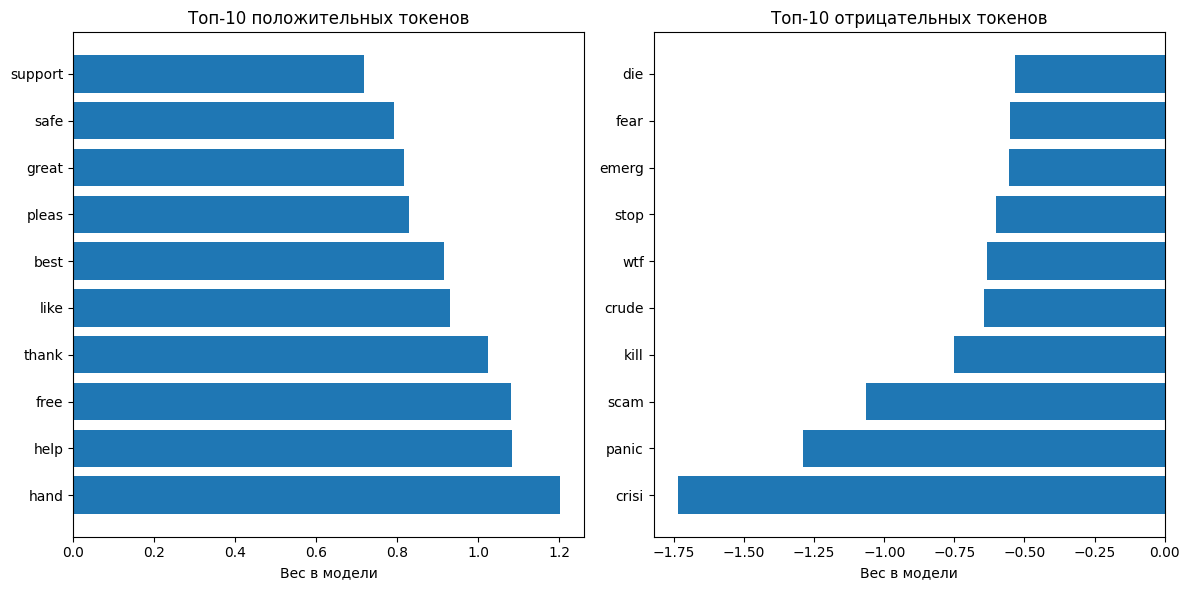

In [ ]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

cv = CountVectorizer(
    tokenizer=custom_stem_tokenizer,
    min_df=8,
    max_features=3700
)
X_train = cv.fit_transform(train['OriginalTweet'])
X_test = cv.transform(test['OriginalTweet'])

scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, solver='liblinear')
lr.fit(X_train_scaled, train['Sentiment_Coded'])

train_acc = accuracy_score(train['Sentiment_Coded'], lr.predict(X_train_scaled))
test_acc = accuracy_score(test['Sentiment_Coded'], lr.predict(X_test_scaled))
print(f"Точность на обучении: {train_acc:.4f}")
print(f"Точность на тесте: {test_acc:.4f}")

feature_names = cv.get_feature_names_out()
coefs = lr.coef_[0]

top_positive = np.argsort(coefs)[-10:][::-1]
top_negative = np.argsort(coefs)[:10]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.barh([feature_names[i] for i in top_positive], coefs[top_positive])
plt.title("Топ-10 положительных токенов")
plt.xlabel("Вес в модели")

plt.subplot(1, 2, 2)
plt.barh([feature_names[i] for i in top_negative], coefs[top_negative])
plt.title("Топ-10 отрицательных токенов")
plt.xlabel("Вес в модели")

plt.tight_layout()
plt.show()

**Ответ:** Модель успешно выделяет ключевые токены для классификации тональности: положительные ("support", "thank") и отрицательные ("die", "scam") имеют четкие веса, но разница в точности (0.94 на обучении vs. 0.85 на тесте) указывает на небольшое переобучение, которое можно уменьшить регуляризацией или улучшением препроцессинга (например, лемматизацией вместо стемминга)

## Задание 7 Другие признаки (1.5 балла)

Мы были сконцентрированы на работе с текстами твиттов и не использовали другие признаки - имена пользователя, дату и местоположение

Изучите признаки UserName и ScreenName. полезны ли они? Если полезны, то закодируйте их, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [ ]:
# -- YOUR CODE HERE --

**Ответ:** # -- YOUR ANSWER HERE --

Изучите признак TweetAt в обучающей выборке: преобразуйте его к типу datetime и нарисуйте его гистограмму с разделением по цвету на основе целевой переменной. Полезен ли он? Если полезен, то закодируйте его, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [ ]:
# -- YOUR CODE HERE --

**Ответ:** # -- YOUR ANSWER HERE --



Поработайте с признаком Location в обучающей выборке. Сколько уникальных значений?

In [ ]:
# -- YOUR CODE HERE --

Постройте гистограмму топ-10 по популярности местоположений (исключая Unknown)

In [ ]:
# -- YOUR CODE HERE --

Видно, что многие местоположения включают в себя более точное название места, чем другие (Например, у некоторых стоит London, UK; а у некоторых просто UK или United Kingdom).

Создайте новый признак WiderLocation, который содержит самое широкое местоположение (например, из London, UK должно получиться UK). Сколько уникальных категорий теперь? Постройте аналогичную гистограмму.

In [ ]:
# -- YOUR CODE HERE --

Закодируйте признак WiderLocation с помощью OHE таким образом, чтобы создались только столбцы для местоположений, которые встречаются более одного раза. Сколько таких значений?


In [ ]:
# -- YOUR CODE HERE --

Добавьте этот признак к матрице отскалированных текстовых признаков, обучите логистическую регрессию, замерьте качество. Как оно изменилось? Оказался ли признак полезным?


*Подсказка:* используйте параметр `categories` в энкодере.

In [ ]:
# -- YOUR CODE HERE --

**Ответ:** # -- YOUR ANSWER HERE --